In [8]:
from collections import namedtuple
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import itertools
import random
import time
import os

In [18]:
KInfo = namedtuple("KInfo", ["half_k", "cnt_groups", "group_size", "dfly_size"])
ht_kinfo = {
    k: KInfo(k//2, 1 + k**2//4, k**2//4 + k, (1 + k**2//4) * (k**2//4 + k))
    for k in KS
}

In [94]:
ht_kinfo

{4: KInfo(half_k=2, cnt_groups=5, group_size=8, dfly_size=40),
 6: KInfo(half_k=3, cnt_groups=10, group_size=15, dfly_size=150),
 8: KInfo(half_k=4, cnt_groups=17, group_size=24, dfly_size=408)}

In [65]:
CNT_TSTEPS = 500
W = 10

EV = lambda k, a, b: 0 if a + b == 0 else k * a / (a + b)

LU, SU0, SU1, SU2, SD = range(5)
EQ, NEQ = range(2)

# CFG_FNAME = "../configs/k_4/config_1_score_-8.txt" # "../configs/k_8/config_9_score_-14.txt"
K = int(CFG_FNAME.split("k_")[1].split('/')[0])

KS = [4, 6, 8]

In [103]:
def get_oog_std(cfg_fname):
    k = int(cfg_fname.split("k_")[1].split('/')[0])

    Z = np.zeros((ht_kinfo[k].cnt_groups, ht_kinfo[k].cnt_groups)) # Z[i, j] = # drumuri 1-indirecte intre gr i si j.

    h = ht_kinfo[k].half_k

    with open(cfg_fname) as fin:
        for line in fin.readlines():
            row = list(map(int, line.strip().split()))
            for sw_start in range(0, len(row), h):
                for a in range(sw_start, sw_start + h):
                    for b in range(a+1, sw_start + h):
                        Z[row[a], row[b]] += 1
                        Z[row[b], row[a]] += 1

    Zc = (ht_kinfo[k].cnt_groups - 2) - Z
    
    # C[t-/t+, lu/su0/su1/su2, g, =].
    # C[t-/t+, sd/lu/su0, g, neq].
    # delta[t, ...].

    C = np.zeros((CNT_TSTEPS * 2, 5, ht_kinfo[k].cnt_groups, 2))
    delta = np.zeros((CNT_TSTEPS, 5, ht_kinfo[k].cnt_groups, 2))

    Z0_sum, Zc0_sum = Z[0, 1:].sum(), Zc[0, 1:].sum()
    for t in range(1, CNT_TSTEPS):
        # group incast catre gr 0.
        for g in range(1, ht_kinfo[k].cnt_groups):
            C[2*t, SD, g, NEQ] = C[2*t-1, SD, g, NEQ] + W/h**2 * (Zc0_sum - Zc[0, g])
            delta[t, SD, g, NEQ] = h**2 * W

            C[2*t, LU, g, NEQ] = C[2*t-1, LU, g, NEQ] + (delta[t-1, SD, g, NEQ] if t else 0)
            C[2*t, LU, g, EQ] = C[2*t-1, LU, g, EQ] + h**2 * W

            delta[t, LU, g, NEQ] = EV(h**2 * W, C[2*t, LU, g, NEQ], C[2*t, LU, g, EQ])
            delta[t, LU, g, EQ] = EV(h**2 * W, C[2*t, LU, g, EQ], C[2*t, LU, g, NEQ])

            C[2*t, SU1, g, EQ] = C[2*t-1, SU1, g, 0] + Z[0, g] / h**2 * (delta[t-1, LU, g, EQ] if t else 0)
            delta[t, SU1, g, EQ] = Z[0, g] * W

            C[2*t, SU2, g, EQ] = C[2*t-1, SU2, g, 0] + Zc[0, g] / h**2 * (delta[t-1, LU, g, EQ] if t else 0)
            delta[t, SU2, g, EQ] = Zc[0, g] * W

            C[2*t, SU0, g, NEQ] = C[2*t-1, SU0, g, NEQ] +\
                                  (delta[t-1, LU, g, NEQ] if t else 0) +\
                                  W / h**2 * (Z0_sum - Z[0, g])
            C[2*t, SU0, g, EQ] = C[2*t-1, SU0, g, EQ] + 1 / h**2 * (delta[t-1, LU, g, EQ] if t else 0)

            delta[t, SU0, g, NEQ] = EV(W, C[2*t, SU0, g, NEQ], C[2*t, SU0, g, EQ])
            delta[t, SU0, g, EQ] = EV(W, C[2*t, SU0, g, EQ], C[2*t, SU0, g, NEQ])

            for sw, eq in [(SD, NEQ), (LU, NEQ), (LU, EQ), (SU1, EQ), (SU2, EQ), (SU0, NEQ), (SU0, EQ)]:
                C[2*t+1, sw, g, eq] = C[2*t, sw, g, eq] - delta[t, sw, g, eq]
                
    OOG = [C[-1, SU0, g, NEQ] + C[-1, SD, g, NEQ] + C[-1, LU, g, NEQ] for g in range(1, ht_kinfo[k].cnt_groups)]
    # print(OOG)
    
    return np.std(OOG, ddof = 1)

In [43]:
"""
k = 4
scor = 0:
[6951.185, 6951.185, 6951.185, 6951.185]
std = 0
scor = -4
[6951.185, 7015.833, 6895.758, 6951.185]
std = 49.09
scor = -6, -8
same ca la -4
scor = -10
[6895.758, 7015.833, 6895.758, 7015.833]
std = 69.32
"""

'\nscor = 0:\n[6951.1856498651905,\n 6951.1856498651905,\n 6951.1856498651905,\n 6951.1856498651905]\n'

In [104]:
get_oog_std("../configs/k_6/config_8_score_-86.txt")

11.71143107228367

In [92]:
def plot_oog_std(k, ax):
    ht_std = {}
    for root, dirs, files in os.walk("../configs"):
        if len(dirs) == 0 and k == int(root.split("/k_")[1].split('/')[0]):
            for file in files:
                score = int(file.split("score_")[1].split('.')[0])
                std = get_oog_std(os.path.join(root, file))
                
                if score not in ht_std:
                    ht_std[score] = []
                ht_std[score].append(std)
                
    for score in ht_std.keys():
        ht_std[score] = np.mean(ht_std[score])
        
    mean_stds = sorted([(score, np.mean(ht_std[score])) for score in ht_std.keys()])
    
    ax.plot([x for x, _ in mean_stds], [y for _, y in mean_stds], ls = '--', marker = 'o')
    ax.set_xlabel("topology score")
    ax.set_ylabel("mean OOG std computed by DP")
    ax.set_title(f"{k = }")

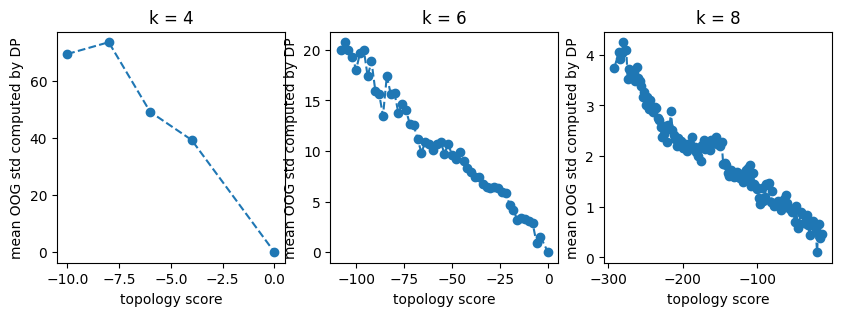

In [100]:
fig, ax = plt.subplots(1, 3, figsize = (10, 3))
for i, k in enumerate(KS):
    plot_oog_std(k, ax[i])